In [1]:
import pandas as pd 

In [6]:
url_Númerodevotos= 'https://github.com/1a2l3o/data_1/raw/refs/heads/main/N%C3%BAmero%20de%20votos.xlsx'

In [8]:
Númerodevotos_df=pd.read_excel(url_Númerodevotos)

In [9]:
print('Númerodevotos:')

Númerodevotos:


In [10]:
print(Númerodevotos_df.head())

     Distrito   voto
0       ancón  13.28
1         ate  17.49
2    barranco  36.92
3       breña  31.15
4  carabayllo  19.24


In [11]:
url_Númerodeiglesias= 'https://github.com/1a2l3o/data_1/raw/refs/heads/main/N%C3%BAmero%20de%20iglesias.xlsx'

In [12]:
Númerodeiglesias_df=pd.read_excel(url_Númerodeiglesias)

In [13]:
print('Númerodeiglesias:')

Númerodeiglesias:


In [14]:
print(Númerodeiglesias_df.head())

     Distrito  iglesias
0       ancón         5
1         ate        10
2    barranco         1
3       breña         2
4  carabayllo         8


In [63]:
url_Númerodereligiones= 'https://github.com/1a2l3o/data_1/raw/refs/heads/main/N%C3%BAmero%20de%20religiones.xlsx'

In [64]:
Númerodereligiones_df=pd.read_excel(url_Númerodereligiones)

In [65]:
print('Númerodereligiones')

Númerodereligiones


In [66]:
print(Númerodereligiones_df.head())

     Distrito  n. de religiones
0       ancón                13
1         ate                15
2    barranco                14
3       breña                15
4  carabayllo                13


In [67]:
url_Ingresopercápita= 'https://github.com/1a2l3o/data_1/raw/refs/heads/main/Ingreso%20per%20c%C3%A1pita.xlsx'

In [68]:
Ingresopercápita_df=pd.read_excel(url_Ingresopercápita)

In [69]:
print('Ingresopercápita:')

Ingresopercápita:


In [70]:
print(Ingresopercápita_df.head())

     Distrito  Ingreso Per Capita
0       ancón               36.27
1         ate              290.87
2    barranco               67.81
3       breña              136.01
4  carabayllo              170.77


In [76]:
df_merge = (
    Ingresopercápita_df.merge(Númerodevotos_df, on='Distrito', how='inner')
              .merge(Númerodeiglesias_df, on='Distrito', how='inner')
              .merge(Númerodereligiones_df, on='Distrito', how='inner')
)

In [77]:
df_merge.head()

,Distrito,Ingreso Per Capita,voto,iglesias,n. de religiones
0,ancón,36.27,13.28,5,13
1,ate,290.87,17.49,10,15
2,barranco,67.81,36.92,1,14
3,breña,136.01,31.15,2,15
4,carabayllo,170.77,19.24,8,13


In [78]:
df_merge.select_dtypes(include='number')

,Ingreso Per Capita,voto,iglesias,n. de religiones
0,36.27,13.28,5,13
1,290.87,17.49,10,15
2,67.81,36.92,1,14
3,136.01,31.15,2,15
4,170.77,19.24,8,13
5,30.78,28.42,1,4
6,245.04,25.27,9,2
7,18.45,20.89,2,2
8,299.64,19.37,13,5
9,112.24,18.28,3,3


In [79]:
variables_numericas= df_merge.select_dtypes(include='number')

In [80]:
correlaciones = variables_numericas.corr()

In [81]:
print("Correlaciones con el % de votos por distrito a Rafael Lopez Aliaga")
print(correlaciones ['voto'].sort_values(ascending=False))

Correlaciones con el % de votos por distrito a Rafael Lopez Aliaga
voto                  1.000000
n. de religiones      0.137377
iglesias             -0.187835
Ingreso Per Capita   -0.193243
Name: voto, dtype: float64


In [82]:
variables_numericas = df_merge.select_dtypes(include='number')

In [83]:
correlaciones_spearman = variables_numericas.corr(method= "spearman")

In [84]:
print("Correlación de spearman con el % de votos por distrito a Rafael López Aliaga:")
print(correlaciones_spearman['voto'].sort_values(ascending=False))

Correlación de spearman con el % de votos por distrito a Rafael López Aliaga:
voto                  1.000000
n. de religiones      0.095933
Ingreso Per Capita    0.050589
iglesias             -0.105352
Name: voto, dtype: float64


In [105]:
!pip install statsmodels 

In [106]:
import statsmodels.api as sm

In [107]:
X = df_merge[['Ingreso Per Capita', 'iglesias', 'n. de religiones']]
#variable dependiente
y = df_merge['voto']
#la constante
X = sm.add_constant(X)

In [108]:
modelo = sm.OLS(y, X).fit()

In [109]:
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:                   voto   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                 -0.020
Method:                 Least Squares   F-statistic:                    0.7285
Date:                Sat, 14 Jun 2025   Prob (F-statistic):              0.541
Time:                        02:13:03   Log-Likelihood:                -168.41
No. Observations:                  43   AIC:                             344.8
Df Residuals:                      39   BIC:                             351.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 27.2531      4

In [110]:
import statsmodels.api as sm

In [113]:
!pip install seaborn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 1.9 MB/s eta 0:00:04
   ----- ---------------------------------- 1.0/8.1 MB 1.7 MB/s eta 0:00:05
   ------ --------------------------------- 1.3/8.1 MB 1.7 MB/s eta 0:00:04
   ------- -------------------------------- 1.6/8.1 MB 1.7 MB/s eta 0:00:04
   ---------- ----------------------------- 2.1/8.1 MB 1.6 MB/s eta 0:00:04
   ---------- ----------------------------- 2.1/8.1 MB 1.6 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.1 MB 1.4 MB/s eta 0:00:05
   ------------- -------------------------- 2.6/8.1 MB 1.4 MB/s eta 0:00:04
   -------------- ------------------------- 2.9/8.1 MB 1.4 MB/s eta 0:00:04
   ---------------- ----------------------- 3.4/8.1 MB 1.4 MB/s eta 0:00:04
   ------------------ --------------------- 3.7/8.1 MB 1.4 MB/s eta 0:00:04
   ------------------- ---

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt

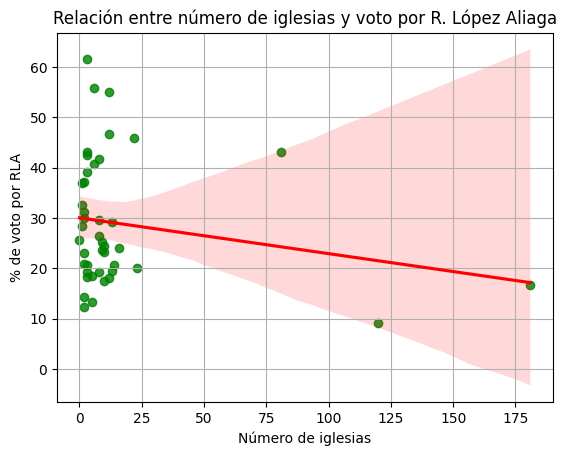

In [116]:
sns.regplot(
    data=df_merged,
    x='iglesias',
    y='voto',
    scatter_kws={'color': 'green'},
    line_kws={'color': 'red'}
)
plt.title('Relación entre número de iglesias y voto por R. López Aliaga')
plt.xlabel('Número de iglesias')
plt.ylabel('% de voto por RLA')
plt.grid(True)
plt.show()

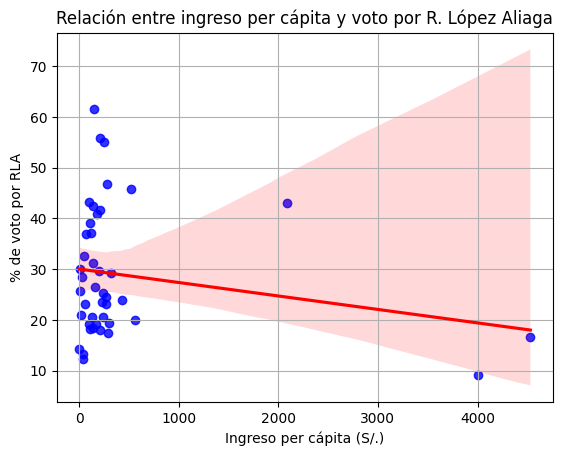

In [117]:
sns.regplot(
    data=df_merged,
    x='Ingreso Per Capita',
    y='voto',
    scatter_kws={'color': 'blue'},
    line_kws={'color': 'red'}
)
plt.title('Relación entre ingreso per cápita y voto por R. López Aliaga')
plt.xlabel('Ingreso per cápita (S/.)')
plt.ylabel('% de voto por RLA')
plt.grid(True)
plt.show()

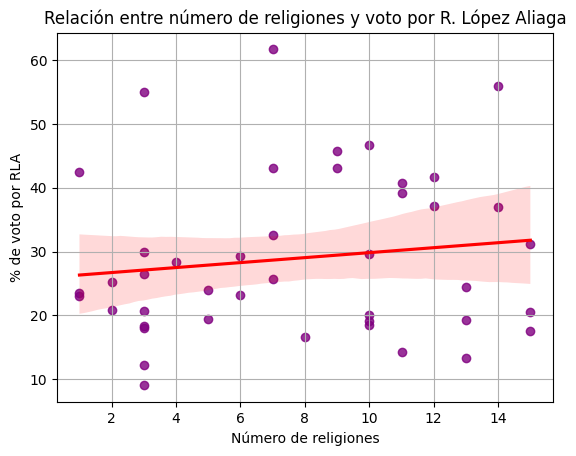

In [118]:
sns.regplot(
    data=df_merged,
    x='n. de religiones',
    y='voto',
    scatter_kws={'color': 'purple'},
    line_kws={'color': 'red'}
)
plt.title('Relación entre número de religiones y voto por R. López Aliaga')
plt.xlabel('Número de religiones')
plt.ylabel('% de voto por RLA')
plt.grid(True)
plt.show()


In [ ]:
df_merged.to_csv("df_merged.csv", index=False)